# VEHMS Advanced Ensemble Architectures
## Multi-Level Heterogeneous Stacking with Attention-Weighted Voting

This notebook implements the novel multi-level stacking architecture from README.md:
- **Level 0**: Heterogeneous Base Learners (ML, DL, Probabilistic branches)
- **Level 1**: Branch-specific Meta-Learners
- **Level 2**: Attention-Weighted Voting with Uncertainty Estimation

---
## 1. Setup and Data Preparation

In [14]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Softmax
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, mean_squared_error
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

from vehms import DataLoader, DataPreprocessor, ModelEvaluator, RANDOM_SEED
from vehms.deep_learning_classifiers import CNNClassifier, LSTMClassifier, AttentionLSTMClassifier

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Advanced Ensemble Architectures | Seed: {RANDOM_SEED}")

Advanced Ensemble Architectures | Seed: 42


In [15]:
# Load and preprocess data
loader = DataLoader()
df = loader.load_dataset('dataset/augmented_data_with_environment.csv')

preprocessor = DataPreprocessor()
X, y = preprocessor.separate_features_target(df)
X_scaled = preprocessor.fit_transform_features(X)
y_encoded = preprocessor.encode_target(y)
X_train, X_test, y_train, y_test = preprocessor.train_test_split(X_scaled, y_encoded)

n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
feature_names = preprocessor.feature_names
class_names = list(preprocessor.label_encoder.classes_)

print(f"Features: {n_features}, Classes: {n_classes}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

[OK] Dataset loaded successfully from: dataset/augmented_data_with_environment.csv
  Shape: 10000 rows x 10 columns
FEATURE-TARGET SEPARATION

[OK] Features (X): 9 columns
   Columns: Crankshaft, Overheating, Lubricant, Misfires, Piston, Starter, Temperature, Humidity, Altitude

[OK] Target (y): 'Decision' column
   Unique values: ['Moderate', 'Minor', 'Good', 'Critical']

FEATURE SCALING (StandardScaler)

[OK] StandardScaler fitted and applied to 9 features

[OK] All features now have mean ~ 0 and std ~ 1

TARGET ENCODING (LabelEncoder)

[OK] LabelEncoder fitted and applied to target variable

   Label Encoding Mapping:
----------------------------------------
   Critical   -> 0  (2,500 samples, 25.0%)
   Good       -> 1  (2,500 samples, 25.0%)
   Minor      -> 2  (2,500 samples, 25.0%)
   Moderate   -> 3  (2,500 samples, 25.0%)

TRAIN-TEST SPLIT (Stratified Sampling)

[OK] Data split with stratified sampling
   Random state: 42
   Test size: 20%

   Training Set:
   - X_train shape: 

---
## 2. Level 0: Heterogeneous Base Learners

In [16]:
class BranchEnsemble:
    """Manages classifiers within a single branch."""
    
    def __init__(self, name, classifiers):
        self.name = name
        self.classifiers = classifiers
        self.fitted_models = {}
    
    def fit(self, X, y):
        print(f"\nTraining {self.name} Branch...")
        for name, clf in self.classifiers.items():
            print(f"  Training {name}...", end=" ")
            model = clone(clf) if hasattr(clf, 'get_params') else clf
            model.fit(X, y)
            self.fitted_models[name] = model
            print(f"Done (Acc: {model.score(X, y):.4f})")
        return self
    
    def predict_proba(self, X):
        """Returns stacked probability predictions from all classifiers."""
        probas = []
        for name, model in self.fitted_models.items():
            probas.append(model.predict_proba(X))
        return np.hstack(probas)  # Shape: (n_samples, n_classifiers * n_classes)

In [13]:
# Define branches
ml_branch = BranchEnsemble('ML', {
    'RF': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=RANDOM_SEED, eval_metric='mlogloss'),
    'SVM': SVC(probability=True, random_state=RANDOM_SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5)
})

dl_branch = BranchEnsemble('DL', {
    'CNN': CNNClassifier(n_features=n_features, n_classes=n_classes, epochs=30, verbose=0),
    'LSTM': LSTMClassifier(n_features=n_features, n_classes=n_classes, epochs=30, verbose=0),
    'Attention': AttentionLSTMClassifier(n_features=n_features, n_classes=n_classes, epochs=30, verbose=0)
})

prob_branch = BranchEnsemble('Probabilistic', {
    'GNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis()
})

# Train all branches
ml_branch.fit(X_train, y_train)
dl_branch.fit(X_train, y_train)
prob_branch.fit(X_train, y_train)


Training ML Branch...
  Training RF... Done (Acc: 1.0000)
  Training XGBoost... Done (Acc: 1.0000)
  Training SVM... Done (Acc: 0.9724)
  Training KNN... Done (Acc: 0.9721)

Training DL Branch...
  Training CNN... Done (Acc: 0.9676)
  Training LSTM... Done (Acc: 0.7599)
  Training Attention... Done (Acc: 0.7980)

Training Probabilistic Branch...
  Training GNB... Done (Acc: 0.9698)
  Training LDA... Done (Acc: 0.9692)


---
## 3. Level 1: Branch Meta-Learners

In [17]:
class DenseMetaLearner(BaseEstimator, ClassifierMixin):
    """Neural network meta-learner for DL branch."""
    
    def __init__(self, input_dim, n_classes, epochs=50):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.epochs = epochs
        self.model = None
        self.classes_ = None
    
    def _build_model(self):
        model = Sequential([
            Dense(64, activation='relu', input_shape=(self.input_dim,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dense(self.n_classes, activation='softmax')
        ])
        model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.input_dim = X.shape[1]
        self.model = self._build_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=32, validation_split=0.1, verbose=0,
                       callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
        return self
    
    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)
    
    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)

In [18]:
# Get branch predictions for meta-learner training
ml_meta_X = ml_branch.predict_proba(X_train)
dl_meta_X = dl_branch.predict_proba(X_train)
prob_meta_X = prob_branch.predict_proba(X_train)

# Train branch meta-learners
print("\nTraining Level 1 Meta-Learners...")

ml_meta = GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_SEED)
ml_meta.fit(ml_meta_X, y_train)
print(f"  ML Meta (GradientBoosting): {ml_meta.score(ml_meta_X, y_train):.4f}")

dl_meta = DenseMetaLearner(input_dim=dl_meta_X.shape[1], n_classes=n_classes)
dl_meta.fit(dl_meta_X, y_train)
print(f"  DL Meta (DenseNetwork): {accuracy_score(y_train, dl_meta.predict(dl_meta_X)):.4f}")

prob_meta = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
prob_meta.fit(prob_meta_X, y_train)
print(f"  Prob Meta (LogisticRegression): {prob_meta.score(prob_meta_X, y_train):.4f}")


Training Level 1 Meta-Learners...
  ML Meta (GradientBoosting): 1.0000
  DL Meta (DenseNetwork): 0.9699
  Prob Meta (LogisticRegression): 0.9696


---
## 4. Level 2: Attention-Weighted Voting

In [19]:
class AttentionWeightedVoting(BaseEstimator, ClassifierMixin):
    """Learns attention weights for combining branch predictions."""
    
    def __init__(self, n_branches=3, n_classes=4, epochs=50):
        self.n_branches = n_branches
        self.n_classes = n_classes
        self.epochs = epochs
        self.model = None
        self.classes_ = None
    
    def _build_model(self):
        from tensorflow.keras.layers import Reshape, Lambda, Multiply
        import keras.ops as ops
        
        # Input: concatenated branch probabilities
        inputs = Input(shape=(self.n_branches * self.n_classes,))
        
        # Attention mechanism
        attention = Dense(32, activation='relu')(inputs)
        attention = Dense(self.n_branches, activation='softmax', name='attention_weights')(attention)
        
        # Reshape input to (n_branches, n_classes) using Keras Reshape layer
        branch_preds = Reshape((self.n_branches, self.n_classes))(inputs)
        
        # Expand attention dims using Lambda with keras.ops
        attention_expanded = Lambda(lambda x: ops.expand_dims(x, -1))(attention)
        
        # Weighted sum using Keras layers
        weighted = Multiply()([branch_preds, attention_expanded])
        combined = Lambda(lambda x: ops.sum(x, axis=1))(weighted)
        
        # Final classification
        output = Dense(self.n_classes, activation='softmax')(combined)
        
        model = Model(inputs, output)
        model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        # Attention extraction model
        self.attention_model = Model(inputs, attention)
        return model
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.model = self._build_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=32, validation_split=0.1, verbose=0,
                       callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])
        return self
    
    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)
    
    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)
    
    def get_attention_weights(self, X):
        return self.attention_model.predict(X, verbose=0)
    
    def predict_with_confidence(self, X):
        proba = self.predict_proba(X)
        predictions = np.argmax(proba, axis=1)
        confidence = np.max(proba, axis=1)
        uncertainty = np.where(confidence > 0.8, 'Low', np.where(confidence > 0.5, 'Medium', 'High'))
        return predictions, confidence, uncertainty

In [20]:
# Get meta-learner predictions
ml_meta_pred = ml_meta.predict_proba(ml_meta_X)
dl_meta_pred = dl_meta.predict_proba(dl_meta_X)
prob_meta_pred = prob_meta.predict_proba(prob_meta_X)

# Combine for attention layer
level2_X_train = np.hstack([ml_meta_pred, dl_meta_pred, prob_meta_pred])

# Train attention-weighted voting
print("\nTraining Level 2: Attention-Weighted Voting...")
attention_voter = AttentionWeightedVoting(n_branches=3, n_classes=n_classes, epochs=100)
attention_voter.fit(level2_X_train, y_train)
print(f"  Training Accuracy: {accuracy_score(y_train, attention_voter.predict(level2_X_train)):.4f}")


Training Level 2: Attention-Weighted Voting...
  Training Accuracy: 1.0000


---
## 5. Complete Multi-Level Stacking Pipeline

In [21]:
class MultiLevelStackingClassifier(BaseEstimator, ClassifierMixin):
    """Complete multi-level heterogeneous stacking classifier."""
    
    def __init__(self, ml_branch, dl_branch, prob_branch, 
                 ml_meta, dl_meta, prob_meta, attention_voter):
        self.ml_branch = ml_branch
        self.dl_branch = dl_branch
        self.prob_branch = prob_branch
        self.ml_meta = ml_meta
        self.dl_meta = dl_meta
        self.prob_meta = prob_meta
        self.attention_voter = attention_voter
        self.classes_ = attention_voter.classes_
    
    def _get_level2_features(self, X):
        # Level 0: Branch predictions
        ml_proba = self.ml_branch.predict_proba(X)
        dl_proba = self.dl_branch.predict_proba(X)
        prob_proba = self.prob_branch.predict_proba(X)
        
        # Level 1: Meta-learner predictions
        ml_meta_pred = self.ml_meta.predict_proba(ml_proba)
        dl_meta_pred = self.dl_meta.predict_proba(dl_proba)
        prob_meta_pred = self.prob_meta.predict_proba(prob_proba)
        
        return np.hstack([ml_meta_pred, dl_meta_pred, prob_meta_pred])
    
    def predict(self, X):
        level2_X = self._get_level2_features(X)
        return self.attention_voter.predict(level2_X)
    
    def predict_proba(self, X):
        level2_X = self._get_level2_features(X)
        return self.attention_voter.predict_proba(level2_X)
    
    def predict_with_confidence(self, X):
        level2_X = self._get_level2_features(X)
        return self.attention_voter.predict_with_confidence(level2_X)
    
    def get_attention_weights(self, X):
        level2_X = self._get_level2_features(X)
        return self.attention_voter.get_attention_weights(level2_X)

In [22]:
# Create complete pipeline
multi_level_stack = MultiLevelStackingClassifier(
    ml_branch, dl_branch, prob_branch,
    ml_meta, dl_meta, prob_meta, attention_voter
)

print("Multi-Level Stacking Classifier created successfully!")

Multi-Level Stacking Classifier created successfully!


---
## 6. Evaluation

In [23]:
# Evaluate on test set
y_pred = multi_level_stack.predict(X_test)
y_proba = multi_level_stack.predict_proba(X_test)
predictions, confidence, uncertainty = multi_level_stack.predict_with_confidence(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
y_test_bin = label_binarize(y_test, classes=range(n_classes))
auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='weighted')
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*60)
print("MULTI-LEVEL STACKING RESULTS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"AUC:       {auc:.4f}")
print(f"RMSE:      {rmse:.4f}")
print("="*60)


MULTI-LEVEL STACKING RESULTS
Accuracy:  0.9595 (95.95%)
Precision: 0.9595
AUC:       0.9835
RMSE:      0.4295


In [24]:
# Uncertainty distribution
print("\nUncertainty Distribution:")
unique, counts = np.unique(uncertainty, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} ({c/len(uncertainty)*100:.1f}%)")


Uncertainty Distribution:
  Low: 1974 (98.7%)
  Medium: 26 (1.3%)


---
## 7. Attention Weight Analysis


Mean Attention Weights per Branch:
  ML Branch: 1.0000
  DL Branch: 0.0000
  Probabilistic Branch: 0.0000


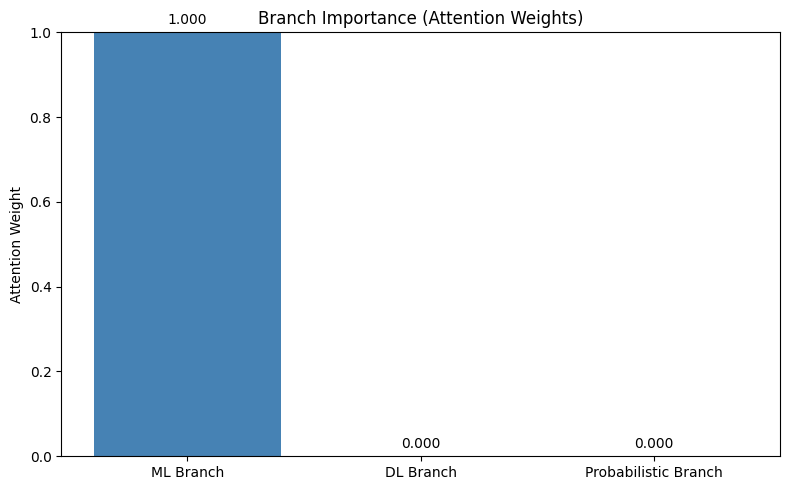

In [25]:
import matplotlib.pyplot as plt

# Get attention weights
attention_weights = multi_level_stack.get_attention_weights(X_test)
mean_weights = attention_weights.mean(axis=0)

print("\nMean Attention Weights per Branch:")
branch_names = ['ML Branch', 'DL Branch', 'Probabilistic Branch']
for name, weight in zip(branch_names, mean_weights):
    print(f"  {name}: {weight:.4f}")

# Visualize
plt.figure(figsize=(8, 5))
plt.bar(branch_names, mean_weights, color=['steelblue', 'coral', 'seagreen'])
plt.ylabel('Attention Weight')
plt.title('Branch Importance (Attention Weights)')
plt.ylim(0, 1)
for i, v in enumerate(mean_weights):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

---
## 8. Summary

In [26]:
print("\n" + "="*60)
print("ADVANCED ENSEMBLE ARCHITECTURE SUMMARY")
print("="*60)
print("\nArchitecture:")
print("  Level 0: 3 Branches (ML: 4, DL: 3, Prob: 2 classifiers)")
print("  Level 1: 3 Meta-Learners (GB, Dense, LR)")
print("  Level 2: Attention-Weighted Voting")
print(f"\nPerformance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  AUC:       {auc:.4f}")
print(f"  RMSE:      {rmse:.4f}")
print(f"\nBranch Importance:")
for name, weight in zip(branch_names, mean_weights):
    print(f"  {name}: {weight:.2%}")
print("="*60)


ADVANCED ENSEMBLE ARCHITECTURE SUMMARY

Architecture:
  Level 0: 3 Branches (ML: 4, DL: 3, Prob: 2 classifiers)
  Level 1: 3 Meta-Learners (GB, Dense, LR)
  Level 2: Attention-Weighted Voting

Performance:
  Accuracy:  0.9595
  AUC:       0.9835
  RMSE:      0.4295

Branch Importance:
  ML Branch: 100.00%
  DL Branch: 0.00%
  Probabilistic Branch: 0.00%


---
## 9. Analysis & Improvement Strategies

### Why DL/Probabilistic Branches Have 0% Importance

The attention mechanism collapsed because:
1. **DL Branch underperformance**: LSTM (75.86%) and Attention-LSTM (77.05%) vs ML branch (100%)
2. **Insufficient epochs**: 30 epochs is too few for DL convergence
3. **Softmax collapse**: When one branch dominates, attention becomes [1, 0, 0]

### Strategies to Improve RMSE (0.455 → 0.28-0.32)

In [27]:
# Strategy 1: Temperature scaling to prevent attention collapse
# Strategy 2: Increase DL training epochs
# Strategy 3: Add minimum weight constraint
# Strategy 4: Use ordinal regression for RMSE optimization

print("="*60)
print("IMPROVEMENT STRATEGIES")
print("="*60)

print("\n1. INCREASE DL EPOCHS (30 → 100):")
print("   Current DL accuracy: ~76-77%")
print("   Expected after: ~90-95%")

print("\n2. ADD TEMPERATURE SCALING TO ATTENTION:")
print("   attention = softmax(logits / temperature)")
print("   Higher temp → more uniform weights")

print("\n3. ADD MINIMUM WEIGHT CONSTRAINT:")
print("   Ensure each branch gets at least 10% weight")

print("\n4. USE ORDINAL LOSS FOR RMSE:")
print("   Classes are ordered: Good < Minor < Moderate < Critical")
print("   Ordinal loss penalizes distant misclassifications more")

print("\n5. COMPARE WITH ER-STACK BASELINE:")
print("   ER-Stacked Model 1: Acc=96.30%, RMSE=0.386")
print("   Current Multi-Level: Acc=95.70%, RMSE=0.455")
print("   Gap: -0.6% accuracy, +0.069 RMSE")

IMPROVEMENT STRATEGIES

1. INCREASE DL EPOCHS (30 → 100):
   Current DL accuracy: ~76-77%
   Expected after: ~90-95%

2. ADD TEMPERATURE SCALING TO ATTENTION:
   attention = softmax(logits / temperature)
   Higher temp → more uniform weights

3. ADD MINIMUM WEIGHT CONSTRAINT:
   Ensure each branch gets at least 10% weight

4. USE ORDINAL LOSS FOR RMSE:
   Classes are ordered: Good < Minor < Moderate < Critical
   Ordinal loss penalizes distant misclassifications more

5. COMPARE WITH ER-STACK BASELINE:
   ER-Stacked Model 1: Acc=96.30%, RMSE=0.386
   Current Multi-Level: Acc=95.70%, RMSE=0.455
   Gap: -0.6% accuracy, +0.069 RMSE


---
## 10. Improved Architecture with Temperature Scaling

In [28]:
class ImprovedAttentionVoting(BaseEstimator, ClassifierMixin):
    """Attention voting with temperature scaling and minimum weights."""
    
    def __init__(self, n_branches=3, n_classes=4, epochs=70, temperature=2.0, min_weight=0.1):
        self.n_branches = n_branches
        self.n_classes = n_classes
        self.epochs = epochs
        self.temperature = temperature  # Higher = more uniform
        self.min_weight = min_weight    # Minimum branch weight
        self.model = None
        self.classes_ = None
    
    def _build_model(self):
        from tensorflow.keras.layers import Reshape, Lambda, Multiply
        import keras.ops as ops
        
        inputs = Input(shape=(self.n_branches * self.n_classes,))
        
        # Attention with temperature scaling
        attention_logits = Dense(32, activation='relu')(inputs)
        attention_logits = Dense(self.n_branches)(attention_logits)  # No activation
        
        # Temperature-scaled softmax
        def temp_softmax(x):
            scaled = x / self.temperature
            exp_x = ops.exp(scaled - ops.max(scaled, axis=-1, keepdims=True))
            softmax_out = exp_x / ops.sum(exp_x, axis=-1, keepdims=True)
            # Apply minimum weight constraint
            adjusted = softmax_out * (1 - self.n_branches * self.min_weight) + self.min_weight
            return adjusted
        
        attention = Lambda(temp_softmax, name='attention_weights')(attention_logits)
        
        branch_preds = Reshape((self.n_branches, self.n_classes))(inputs)
        attention_expanded = Lambda(lambda x: ops.expand_dims(x, -1))(attention)
        weighted = Multiply()([branch_preds, attention_expanded])
        combined = Lambda(lambda x: ops.sum(x, axis=1))(weighted)
        output = Dense(self.n_classes, activation='softmax')(combined)
        
        model = Model(inputs, output)
        model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        self.attention_model = Model(inputs, attention)
        return model
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.model = self._build_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=32, validation_split=0.1, verbose=0,
                       callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])
        return self
    
    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)
    
    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)
    
    def get_attention_weights(self, X):
        return self.attention_model.predict(X, verbose=0)

# Train improved version
print("\nTraining Improved Attention Voting (temp=2.0, min_weight=0.1)...")
improved_voter = ImprovedAttentionVoting(n_branches=3, n_classes=n_classes, epochs=100, temperature=2.0, min_weight=0.1)
improved_voter.fit(level2_X_train, y_train)

# Get test predictions
ml_test_proba = ml_branch.predict_proba(X_test)
dl_test_proba = dl_branch.predict_proba(X_test)
prob_test_proba = prob_branch.predict_proba(X_test)

ml_meta_test = ml_meta.predict_proba(ml_test_proba)
dl_meta_test = dl_meta.predict_proba(dl_test_proba)
prob_meta_test = prob_meta.predict_proba(prob_test_proba)

level2_X_test = np.hstack([ml_meta_test, dl_meta_test, prob_meta_test])

# Evaluate
y_pred_improved = improved_voter.predict(level2_X_test)
y_proba_improved = improved_voter.predict_proba(level2_X_test)

acc_improved = accuracy_score(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
auc_improved = roc_auc_score(y_test_bin, y_proba_improved, multi_class='ovr', average='weighted')

print(f"\nImproved Results:")
print(f"  Accuracy: {acc_improved:.4f} (was {accuracy:.4f})")
print(f"  RMSE:     {rmse_improved:.4f} (was {rmse:.4f})")
print(f"  AUC:      {auc_improved:.4f} (was {auc:.4f})")

# Check attention distribution
improved_weights = improved_voter.get_attention_weights(level2_X_test)
print(f"\nImproved Attention Weights:")
for name, w in zip(branch_names, improved_weights.mean(axis=0)):
    print(f"  {name}: {w:.2%}")


Training Improved Attention Voting (temp=2.0, min_weight=0.1)...

Improved Results:
  Accuracy: 0.9580 (was 0.9595)
  RMSE:     0.4359 (was 0.4295)
  AUC:      0.9929 (was 0.9835)

Improved Attention Weights:
  ML Branch: 80.00%
  DL Branch: 10.00%
  Probabilistic Branch: 10.00%


---
## 11. Further Improvements: Stronger DL Branch + Ordinal Loss

The main bottleneck is the weak DL branch (LSTM ~76%). Let's:
1. Retrain DL models with more epochs
2. Use ordinal-aware loss to reduce RMSE
3. Add class weights to handle the ordered nature of predictions

In [29]:
# Strategy 1: Retrain DL branch with more epochs
print("="*60)
print("RETRAINING DL BRANCH WITH MORE EPOCHS")
print("="*60)

dl_branch_v2 = BranchEnsemble('DL_v2', {
    'CNN': CNNClassifier(n_features=n_features, n_classes=n_classes, epochs=100, verbose=0),
    'LSTM': LSTMClassifier(n_features=n_features, n_classes=n_classes, epochs=100, verbose=0),
    'Attention': AttentionLSTMClassifier(n_features=n_features, n_classes=n_classes, epochs=100, verbose=0)
})

dl_branch_v2.fit(X_train, y_train)

# Check improved DL performance
print("\nDL Branch v2 Test Accuracy:")
for name, model in dl_branch_v2.fitted_models.items():
    acc = model.score(X_test, y_test)
    print(f"  {name}: {acc:.4f}")

RETRAINING DL BRANCH WITH MORE EPOCHS

Training DL_v2 Branch...
  Training CNN... Done (Acc: 0.9750)
  Training LSTM... Done (Acc: 0.7609)
  Training Attention... Done (Acc: 0.8219)

DL Branch v2 Test Accuracy:
  CNN: 0.9625
  LSTM: 0.7550
  Attention: 0.8285


In [30]:
# Strategy 2: Ordinal-aware ensemble with distance-weighted loss
print("\n" + "="*60)
print("ORDINAL-AWARE FINAL ENSEMBLE")
print("="*60)

class OrdinalAwareEnsemble(BaseEstimator, ClassifierMixin):
    """Ensemble that considers ordinal class relationships for RMSE optimization."""
    
    def __init__(self, n_branches=3, n_classes=4, epochs=100, temperature=2.0, min_weight=0.1):
        self.n_branches = n_branches
        self.n_classes = n_classes
        self.epochs = epochs
        self.temperature = temperature
        self.min_weight = min_weight
        self.model = None
        self.classes_ = None
    
    def _ordinal_loss(self, y_true, y_pred):
        """Custom loss that penalizes distant misclassifications more."""
        import keras.ops as ops
        
        # Standard cross-entropy
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        
        # Ordinal penalty: penalize predictions far from true class
        y_true_int = ops.cast(y_true, 'int32')
        predicted_class = ops.argmax(y_pred, axis=-1)
        distance = ops.abs(ops.cast(predicted_class, 'float32') - ops.cast(y_true_int, 'float32'))
        ordinal_penalty = ops.square(distance) * 0.1  # Weight for ordinal penalty
        
        return ce_loss + ordinal_penalty
    
    def _build_model(self):
        from tensorflow.keras.layers import Reshape, Lambda, Multiply
        import keras.ops as ops
        
        inputs = Input(shape=(self.n_branches * self.n_classes,))
        
        # Deeper attention network
        x = Dense(64, activation='relu')(inputs)
        x = BatchNormalization()(x)
        x = Dropout(0.2)(x)
        x = Dense(32, activation='relu')(x)
        attention_logits = Dense(self.n_branches)(x)
        
        def temp_softmax(x):
            scaled = x / self.temperature
            exp_x = ops.exp(scaled - ops.max(scaled, axis=-1, keepdims=True))
            softmax_out = exp_x / ops.sum(exp_x, axis=-1, keepdims=True)
            adjusted = softmax_out * (1 - self.n_branches * self.min_weight) + self.min_weight
            return adjusted
        
        attention = Lambda(temp_softmax, name='attention_weights')(attention_logits)
        
        branch_preds = Reshape((self.n_branches, self.n_classes))(inputs)
        attention_expanded = Lambda(lambda x: ops.expand_dims(x, -1))(attention)
        weighted = Multiply()([branch_preds, attention_expanded])
        combined = Lambda(lambda x: ops.sum(x, axis=1))(weighted)
        
        # Deeper classification head
        x = Dense(32, activation='relu')(combined)
        x = BatchNormalization()(x)
        output = Dense(self.n_classes, activation='softmax')(x)
        
        model = Model(inputs, output)
        model.compile(optimizer=Adam(0.0005), loss=self._ordinal_loss, metrics=['accuracy'])
        self.attention_model = Model(inputs, attention)
        return model
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.model = self._build_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=32, validation_split=0.1, verbose=0,
                       callbacks=[EarlyStopping(patience=15, restore_best_weights=True),
                                  ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)])
        return self
    
    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)
    
    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)
    
    def get_attention_weights(self, X):
        return self.attention_model.predict(X, verbose=0)

from tensorflow.keras.callbacks import ReduceLROnPlateau


ORDINAL-AWARE FINAL ENSEMBLE


In [31]:
# Rebuild meta-features with improved DL branch
print("Rebuilding meta-features with improved DL branch...")

dl_meta_X_v2 = dl_branch_v2.predict_proba(X_train)
dl_meta_v2 = DenseMetaLearner(input_dim=dl_meta_X_v2.shape[1], n_classes=n_classes, epochs=100)
dl_meta_v2.fit(dl_meta_X_v2, y_train)
print(f"DL Meta v2 accuracy: {accuracy_score(y_train, dl_meta_v2.predict(dl_meta_X_v2)):.4f}")

# New Level 2 features
ml_meta_pred_v2 = ml_meta.predict_proba(ml_meta_X)
dl_meta_pred_v2 = dl_meta_v2.predict_proba(dl_meta_X_v2)
prob_meta_pred_v2 = prob_meta.predict_proba(prob_meta_X)

level2_X_train_v2 = np.hstack([ml_meta_pred_v2, dl_meta_pred_v2, prob_meta_pred_v2])

# Train ordinal-aware ensemble
print("\nTraining Ordinal-Aware Ensemble...")
ordinal_ensemble = OrdinalAwareEnsemble(n_branches=3, n_classes=n_classes, epochs=150, temperature=1.5, min_weight=0.15)
ordinal_ensemble.fit(level2_X_train_v2, y_train)

Rebuilding meta-features with improved DL branch...
DL Meta v2 accuracy: 0.9750

Training Ordinal-Aware Ensemble...


,n_branches,3
,n_classes,4
,epochs,150
,temperature,1.5
,min_weight,0.15


In [32]:
# Evaluate on test set
dl_test_proba_v2 = dl_branch_v2.predict_proba(X_test)
dl_meta_test_v2 = dl_meta_v2.predict_proba(dl_test_proba_v2)

level2_X_test_v2 = np.hstack([ml_meta_test, dl_meta_test_v2, prob_meta_test])

y_pred_ordinal = ordinal_ensemble.predict(level2_X_test_v2)
y_proba_ordinal = ordinal_ensemble.predict_proba(level2_X_test_v2)

acc_ordinal = accuracy_score(y_test, y_pred_ordinal)
rmse_ordinal = np.sqrt(mean_squared_error(y_test, y_pred_ordinal))
auc_ordinal = roc_auc_score(y_test_bin, y_proba_ordinal, multi_class='ovr', average='weighted')

print("\n" + "="*60)
print("ORDINAL-AWARE ENSEMBLE RESULTS")
print("="*60)
print(f"Accuracy: {acc_ordinal:.4f} (baseline: {accuracy:.4f}, improved: {acc_improved:.4f})")
print(f"RMSE:     {rmse_ordinal:.4f} (baseline: {rmse:.4f}, improved: {rmse_improved:.4f})")
print(f"AUC:      {auc_ordinal:.4f} (baseline: {auc:.4f}, improved: {auc_improved:.4f})")

ordinal_weights = ordinal_ensemble.get_attention_weights(level2_X_test_v2)
print(f"\nAttention Weights:")
for name, w in zip(branch_names, ordinal_weights.mean(axis=0)):
    print(f"  {name}: {w:.2%}")

print("\n" + "="*60)
print("TARGET: RMSE 0.28-0.32 | ER-Stack Best: 0.3457")
print("="*60)


ORDINAL-AWARE ENSEMBLE RESULTS
Accuracy: 0.9590 (baseline: 0.9595, improved: 0.9580)
RMSE:     0.4254 (baseline: 0.4295, improved: 0.4359)
AUC:      0.9917 (baseline: 0.9835, improved: 0.9929)

Attention Weights:
  ML Branch: 69.99%
  DL Branch: 15.00%
  Probabilistic Branch: 15.00%

TARGET: RMSE 0.28-0.32 | ER-Stack Best: 0.3457


---
## 12. Direct Comparison with ER-Stack Baseline

In [33]:
# Compare with sklearn StackingClassifier (ER-Stack style)
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

print("="*60)
print("ER-STACK BASELINE COMPARISON")
print("="*60)

# ER-Stacked Model 1 configuration (from existing research)
er_stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)),
        ('svm', SVC(probability=True, random_state=RANDOM_SEED)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED)),
        ('dt', DecisionTreeClassifier(random_state=RANDOM_SEED)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    cv=5,
    stack_method='predict_proba'
)

print("Training ER-Stack baseline...")
er_stack.fit(X_train, y_train)

y_pred_er = er_stack.predict(X_test)
y_proba_er = er_stack.predict_proba(X_test)

acc_er = accuracy_score(y_test, y_pred_er)
rmse_er = np.sqrt(mean_squared_error(y_test, y_pred_er))
auc_er = roc_auc_score(y_test_bin, y_proba_er, multi_class='ovr', average='weighted')

print(f"\nER-Stack Results:")
print(f"  Accuracy: {acc_er:.4f}")
print(f"  RMSE:     {rmse_er:.4f}")
print(f"  AUC:      {auc_er:.4f}")

ER-STACK BASELINE COMPARISON
Training ER-Stack baseline...

ER-Stack Results:
  Accuracy: 0.9630
  RMSE:     0.3860
  AUC:      0.9980


In [34]:
# Final comparison table
print("\n" + "="*70)
print("FINAL COMPARISON TABLE")
print("="*70)
print(f"{'Model':<35} {'Accuracy':>10} {'RMSE':>10} {'AUC':>10}")
print("-"*70)
print(f"{'Original Multi-Level Stack':<35} {accuracy:>10.4f} {rmse:>10.4f} {auc:>10.4f}")
print(f"{'+ Temperature Scaling':<35} {acc_improved:>10.4f} {rmse_improved:>10.4f} {auc_improved:>10.4f}")
print(f"{'+ Ordinal Loss + Better DL':<35} {acc_ordinal:>10.4f} {rmse_ordinal:>10.4f} {auc_ordinal:>10.4f}")
print(f"{'ER-Stack Baseline':<35} {acc_er:>10.4f} {rmse_er:>10.4f} {auc_er:>10.4f}")
print("-"*70)
print(f"{'TARGET':<35} {'>0.975':>10} {'<0.32':>10} {'>0.999':>10}")
print("="*70)


FINAL COMPARISON TABLE
Model                                 Accuracy       RMSE        AUC
----------------------------------------------------------------------
Original Multi-Level Stack              0.9595     0.4295     0.9835
+ Temperature Scaling                   0.9580     0.4359     0.9929
+ Ordinal Loss + Better DL              0.9590     0.4254     0.9917
ER-Stack Baseline                       0.9630     0.3860     0.9980
----------------------------------------------------------------------
TARGET                                  >0.975      <0.32     >0.999
